In [ ]:
# 사전 준비
'''
../practice4/output/vip_*.csv data/의 파일들을
현 디렉토리의 data 폴더 안에 넣어주세요.
'''

'\n../practice4/output/vip_*.csv data/의 파일들을\n현 디렉토리의 data 폴더 안에 넣어주세요.\n'

In [ ]:
# 시나리오 설명
'''
김싸피는 VIP 고객 데이터를 분석하여
월별 매출 흐름을 시각화하고, 각 카테고리별로 요약 통계를 정리한 보고서를 작성하려고 합니다.
이는 마케팅/영업팀에 전달되어 전략 수립에 활용됩니다.
'''

'\n김싸피는 VIP 고객 데이터를 분석하여\n일별 매출 흐름을 시각화하고, 각 카테고리별로 요약 통계를 정리한 보고서를 작성하려고 합니다.\n이는 마케팅/영업팀에 전달되어 전략 수립에 활용됩니다.\n'

In [ ]:
# 요구 사항
'''
vip_*.csv 파일을 순회하며 읽어옵니다.
invoicedate를 datetime으로 변환한 후, 월 기준으로 그룹핑합니다.
카테고리별 월별 total_revenue 시계열 그래프를 생성하세요.
count, mean, sum 중심의 요약 통계를 출력합니다.
시각화는 라인 그래프 1개씩 출력하세요.
'''

'\nvip_*.csv 파일을 순회하며 읽어옵니다.\ninvoicedate를 datetime으로 변환한 후, 일자 기준으로 그룹핑합니다.\n카테고리별 월별 total_revenue 시계열 그래프를 생성하세요.\ncount, mean, sum 중심의 요약 통계를 출력합니다.\n시각화는 라인 그래프 1개씩 출력하세요.\n'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

In [2]:
data_dir="../data"
    


Accessories - 월별 분석 보고
분석 개월 수: 69개월
월간 매출 평균: 147924.11
전체 누적 매출: 10206763.26


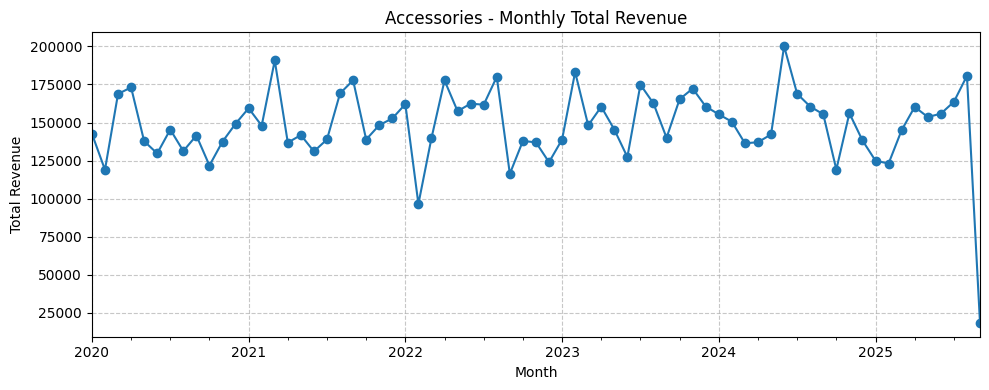


Apparel - 월별 분석 보고
분석 개월 수: 69개월
월간 매출 평균: 146491.93
전체 누적 매출: 10107943.17


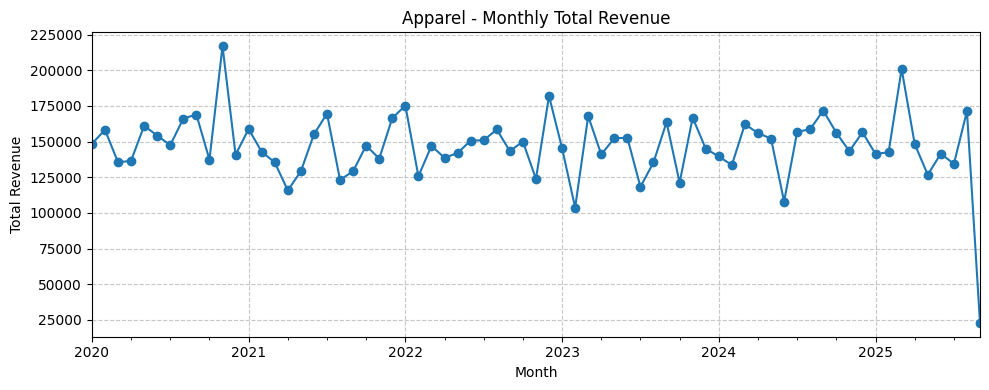


Electronics - 월별 분석 보고
분석 개월 수: 69개월
월간 매출 평균: 146786.47
전체 누적 매출: 10128266.62


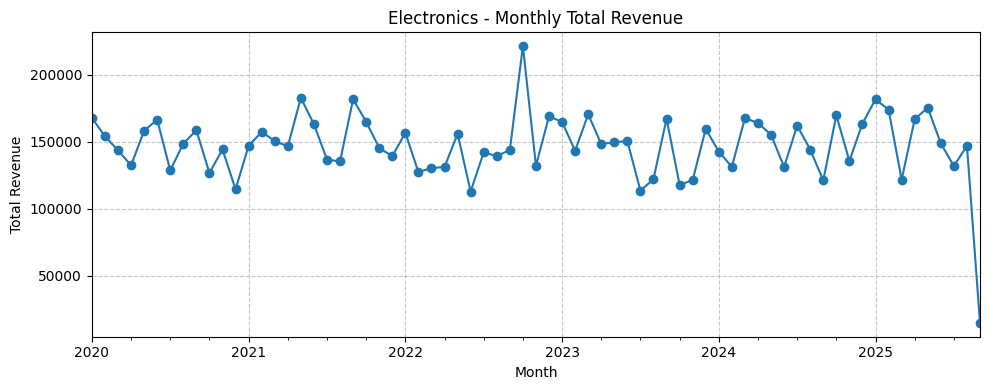


Furniture - 월별 분석 보고
분석 개월 수: 69개월
월간 매출 평균: 148923.45
전체 누적 매출: 10275717.86


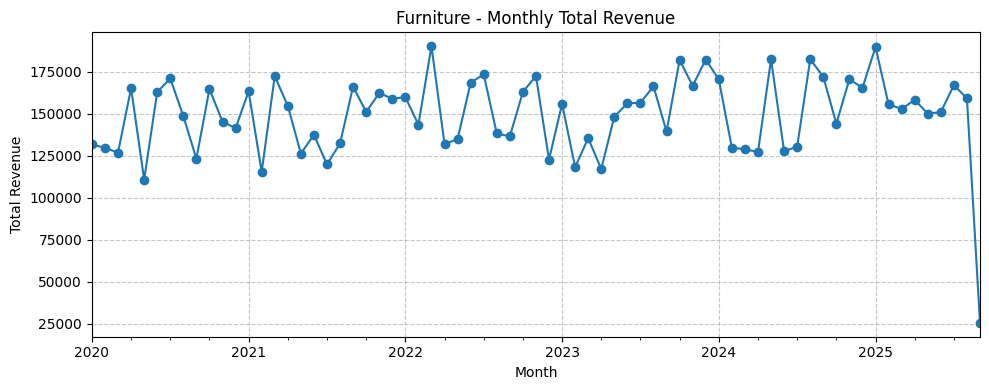


Stationery - 월별 분석 보고
분석 개월 수: 69개월
월간 매출 평균: 146213.58
전체 누적 매출: 10088736.92


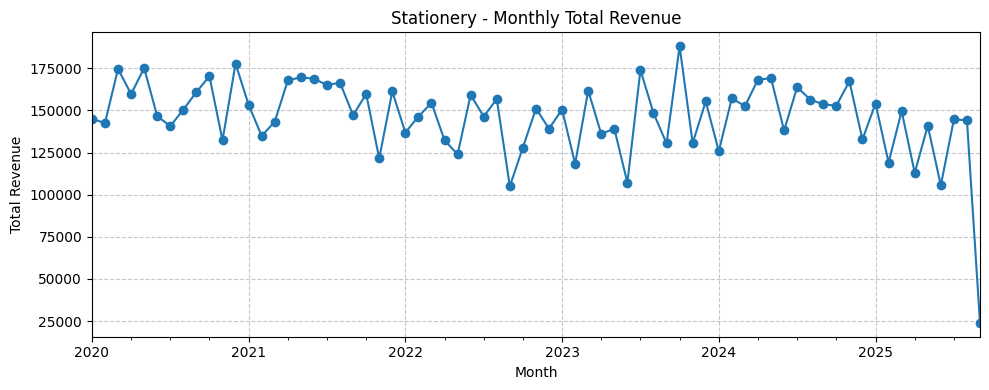

In [3]:
"""
vip_*.csv 파일들을 불러와 월별 매출 통계 요약 및 시계열 시각화를 수행한다.
"""
# 1. 파일 패턴 지정 (vip_로 시작하는 csv)
file_list = glob.glob(os.path.join(data_dir, "vip_*.csv"))

for file_path in file_list:
    category = os.path.basename(file_path).replace("vip_", "").replace(".csv", "").replace("_", " ").title()
    df = pd.read_csv(file_path)

    # 수익(total_revenue) 계산
    if "total_revenue" not in df.columns and {"quantity", "unitprice"} <= set(df.columns):
        df["total_revenue"] = df["quantity"] * df["unitprice"]

    # 날짜 데이터 처리 및 인덱스 설정
    df["invoicedate"] = pd.to_datetime(df["invoicedate"], errors="coerce")
    df.dropna(subset=["invoicedate", "total_revenue"], inplace=True)
    
    # [중요] 시계열 분석(Resampling)을 위해 날짜 컬럼을 인덱스로 설정하세요.
    df.set_index(keys="invoicedate", inplace=True)

    # 2. 월 단위(Month End)로 매출 합계 재구성
    # 최신 버전에서는 'M' 대신 '____'를 권장합니다.
    monthly_df = df["total_revenue"].resample('ME').sum()

    # 3. 요약 통계 출력 (월간 합계 기준)
    print(f"\n{category} - 월별 분석 보고")
    print(f"분석 개월 수: {len(monthly_df)}개월")
    
    # 월별 매출액들의 평균값과 전체 총합을 구하세요.
    print(f"월간 매출 평균: {monthly_df.mean():.2f}")
    print(f"전체 누적 매출: {monthly_df.sum():.2f}")

    try:
        # 데이터가 부족할 경우 시각화 건너뛰기
        if len(monthly_df) < 2:
            print(f"{category} 데이터 부족으로 시각화 생략")
            continue

        # 4. 월간 매출 그래프 생성
        plt.figure(figsize=(10, 4))
        
        # 선 그래프에 점(marker)을 찍어 가독성을 높이세요.
        monthly_df.plot(marker='o', linestyle='-')
        
        plt.title(f"{category} - Monthly Total Revenue")
        plt.xlabel("Month")
        plt.ylabel("Total Revenue")
        
        # 그래프 배경에 격자를 추가하여 수치를 보기 편하게 만드세요.
        plt.grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"{category} 시각화 실패: {e}")